# Time Series Anomaly Detection – EDA

## Dataset: Batch Distillation Process Monitoring

This notebook performs exploratory data analysis on multivariate industrial time series data collected from a batch distillation system.

Goal:
- Understand sensor behavior
- Identify patterns and anomalies
- Explore temporal structure

In [109]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [91]:
import json

with open("../data/manifest.json", "r") as f:
    manifest = json.load(f)

manifest

{'dataset_name': 'lab_batch_distillation_task_02',
 'split_name': 'public_train_validation_test_package',
 'feature_columns': ['LS701',
  'LS702',
  'T701',
  'T702',
  'T703',
  'T704',
  'T706',
  'T708',
  'T709',
  'T711',
  'T712',
  'T705',
  'FT703',
  'FT704',
  'PDI701',
  'PDI702',
  'PY23',
  'FYI702'],
 'feature_descriptions': {'LS701': 'Fluid level in the reboiler vessel.',
  'LS702': 'Fluid level in the buffer vessel.',
  'T701': 'Temperature at the lower heating-jacket hemisphere of the reboiler.',
  'T702': 'Temperature at the upper heating-jacket hemisphere of the reboiler.',
  'T703': 'Liquid residue temperature in the reboiler vessel.',
  'T704': 'Temperature at the middle heating jacket.',
  'T706': 'Temperature at the bottom heating jacket.',
  'T708': 'Temperature at the top heating jacket.',
  'T709': 'Temperature sensor inside the distillation column.',
  'T711': 'Temperature sensor inside the distillation column.',
  'T712': 'Temperature sensor inside the disti

In [92]:
df = pd.read_csv("../data/val/series_002.csv")
labels = pd.read_csv("../data/val_labels/series_002.csv")

df.head()

,LS701,LS702,T701,T702,T703,T704,T706,T708,T709,T711,T712,T705,FT703,FT704,PDI701,PDI702,PY23,FYI702
0,1.0,1.0,439.0,70.3,69.6,70.0,70.0,70.0,68.2,63.4,63.4,63.3,0.0,0.1,0.6,2.9,498.5,6.8
1,1.0,1.0,439.1,70.3,69.6,70.0,70.0,70.0,68.2,63.4,63.3,63.3,0.0,0.1,0.6,3.0,498.7,7.3
2,1.0,1.0,439.2,70.3,69.6,70.0,70.0,70.0,68.2,63.4,63.3,63.3,0.0,0.1,0.6,3.2,499.0,6.8
3,1.0,1.0,439.1,70.2,69.6,70.0,70.0,70.0,68.2,63.4,63.3,63.3,0.1,0.7,0.6,3.2,499.2,6.8
4,1.0,1.0,439.1,70.2,69.6,70.0,70.0,70.0,68.2,63.4,63.3,63.3,0.2,1.2,0.6,3.1,499.3,7.3


In [93]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   LS701   11195 non-null  float64
 1   LS702   11195 non-null  float64
 2   T701    11195 non-null  float64
 3   T702    11195 non-null  float64
 4   T703    11195 non-null  float64
 5   T704    11195 non-null  float64
 6   T706    11195 non-null  float64
 7   T708    11195 non-null  float64
 8   T709    11195 non-null  float64
 9   T711    11195 non-null  float64
 10  T712    11195 non-null  float64
 11  T705    11195 non-null  float64
 12  FT703   11195 non-null  float64
 13  FT704   11195 non-null  float64
 14  PDI701  11195 non-null  float64
 15  PDI702  11195 non-null  float64
 16  PY23    11195 non-null  float64
 17  FYI702  11195 non-null  float64
dtypes: float64(18)
memory usage: 1.5 MB


,LS701,LS702,T701,T702,T703,T704,T706,T708,T709,T711,T712,T705,FT703,FT704,PDI701,PDI702,PY23,FYI702
count,11195.000000,11195.0,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000
mean,0.999285,1.0,443.003153,70.249571,71.243176,69.998508,70.002604,70.008334,69.441032,63.337043,63.337575,63.295757,0.110621,0.519893,0.624819,2.990259,499.883189,6.915949
std,0.026724,0.0,1.177573,0.294461,1.091779,0.024190,0.065716,0.033653,0.933450,0.048690,0.048826,0.045592,0.134893,0.238855,0.062008,0.162599,0.932638,0.380371
min,0.000000,1.0,439.000000,69.700000,69.600000,69.900000,69.900000,69.900000,68.100000,63.200000,63.200000,62.300000,0.000000,0.000000,0.400000,-0.400000,494.600000,5.800000
25%,1.000000,1.0,442.300000,70.000000,70.300000,70.000000,70.000000,70.000000,68.600000,63.300000,63.300000,63.300000,0.100000,0.400000,0.600000,3.000000,499.200000,6.800000
50%,1.000000,1.0,443.300000,70.300000,71.100000,70.000000,70.000000,70.000000,69.300000,63.300000,63.300000,63.300000,0.100000,0.500000,0.600000,3.000000,499.800000,6.800000
75%,1.000000,1.0,443.800000,70.500000,72.100000,70.000000,70.000000,70.000000,70.200000,63.400000,63.400000,63.300000,0.100000,0.600000,0.700000,3.000000,500.600000,7.300000
max,1.000000,1.0,444.900000,70.900000,73.500000,70.100000,70.300000,70.200000,71.500000,63.400000,63.400000,63.300000,2.800000,5.100000,0.900000,5.400000,502.500000,7.800000


In [94]:
df['anomaly'] = labels['label']
df.head()

,LS701,LS702,T701,T702,T703,T704,T706,T708,T709,T711,T712,T705,FT703,FT704,PDI701,PDI702,PY23,FYI702,anomaly
0,1.0,1.0,439.0,70.3,69.6,70.0,70.0,70.0,68.2,63.4,63.4,63.3,0.0,0.1,0.6,2.9,498.5,6.8,0
1,1.0,1.0,439.1,70.3,69.6,70.0,70.0,70.0,68.2,63.4,63.3,63.3,0.0,0.1,0.6,3.0,498.7,7.3,0
2,1.0,1.0,439.2,70.3,69.6,70.0,70.0,70.0,68.2,63.4,63.3,63.3,0.0,0.1,0.6,3.2,499.0,6.8,0
3,1.0,1.0,439.1,70.2,69.6,70.0,70.0,70.0,68.2,63.4,63.3,63.3,0.1,0.7,0.6,3.2,499.2,6.8,0
4,1.0,1.0,439.1,70.2,69.6,70.0,70.0,70.0,68.2,63.4,63.3,63.3,0.2,1.2,0.6,3.1,499.3,7.3,0


In [95]:
df['anomaly'].value_counts()

anomaly
0    10851
1      344
Name: count, dtype: int64

In [96]:
df['anomaly'].value_counts(normalize=True)

anomaly
0    0.969272
1    0.030728
Name: proportion, dtype: float64

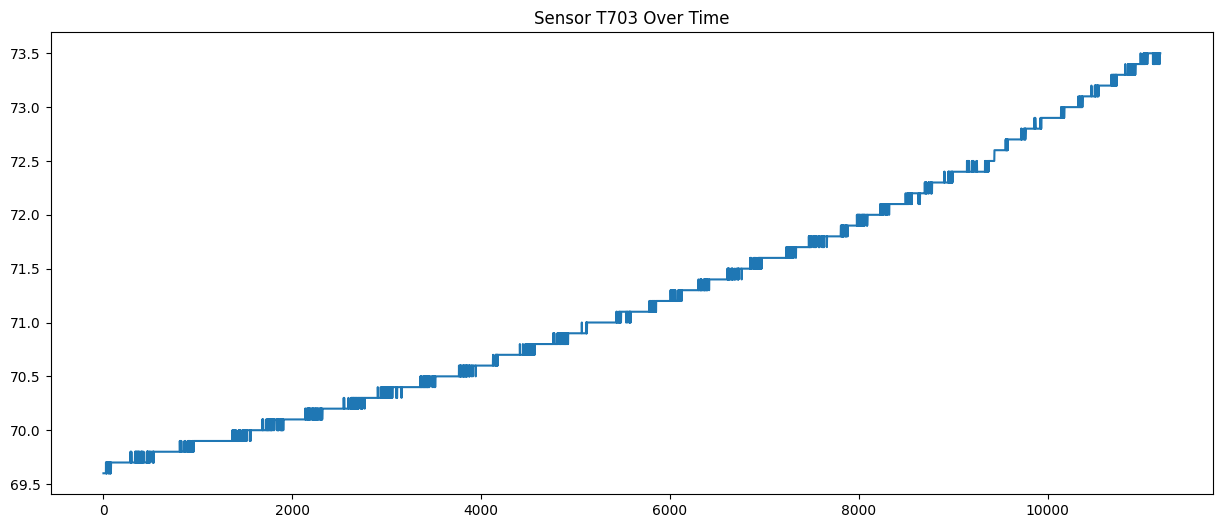

In [97]:
plt.figure(figsize=(15,6))
plt.plot(df.index, df['T703'])
plt.title("Sensor T703 Over Time")
plt.show()

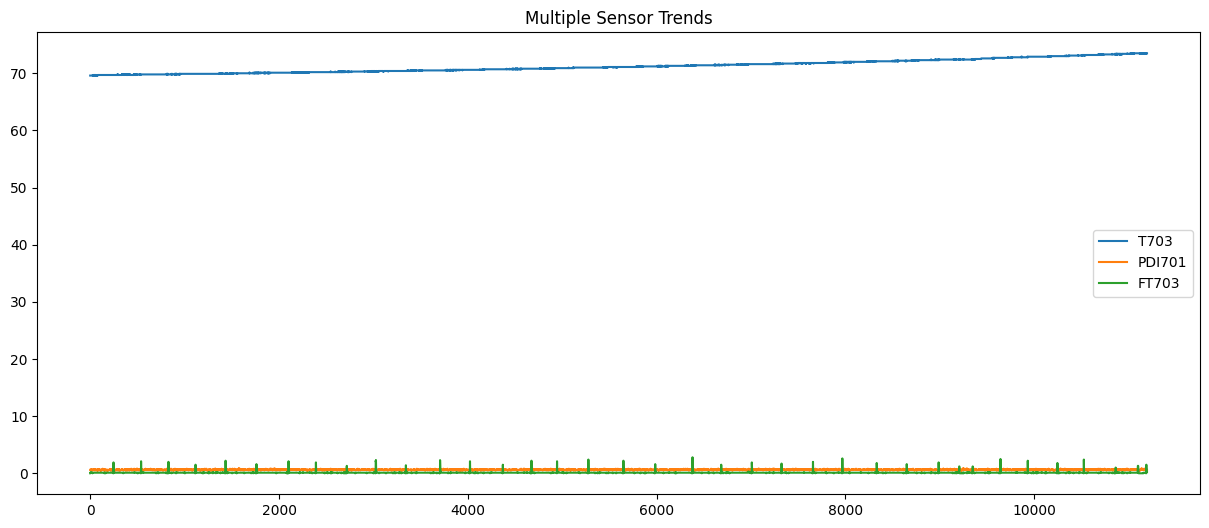

In [98]:
sensors = ['T703', 'PDI701', 'FT703']

df[sensors].plot(figsize=(15,6))
plt.title("Multiple Sensor Trends")
plt.show()

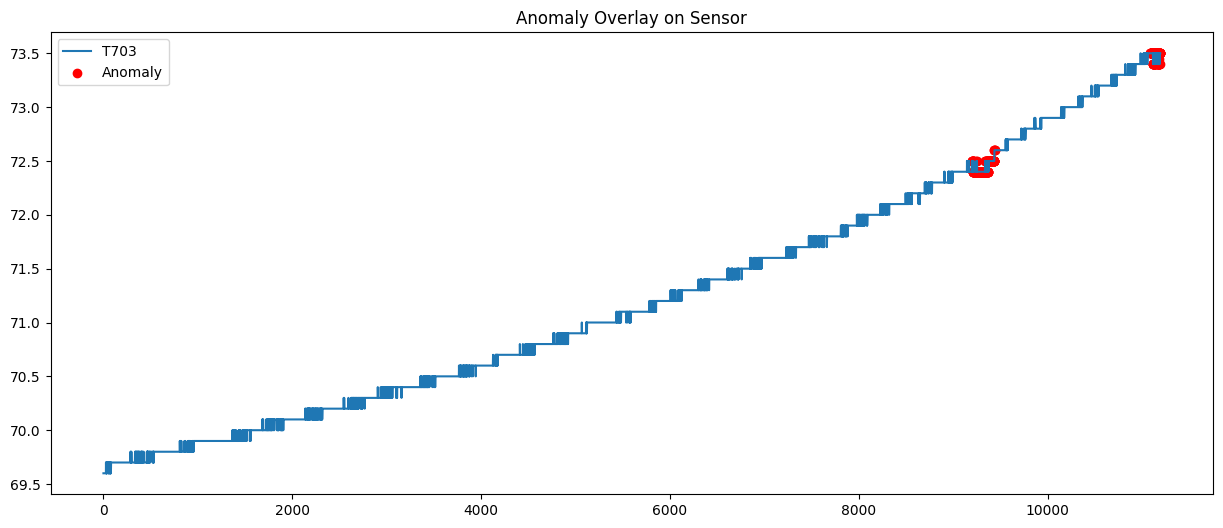

In [99]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df['T703'], label='T703')

anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['T703'], color='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Overlay on Sensor")
plt.show()

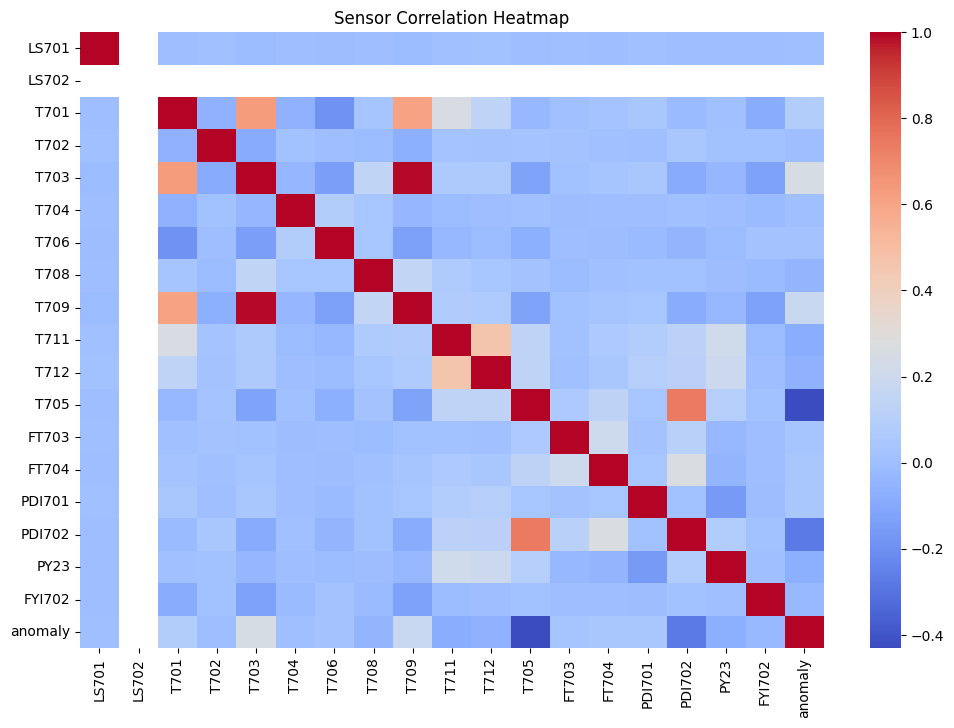

In [100]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Sensor Correlation Heatmap")
plt.show()

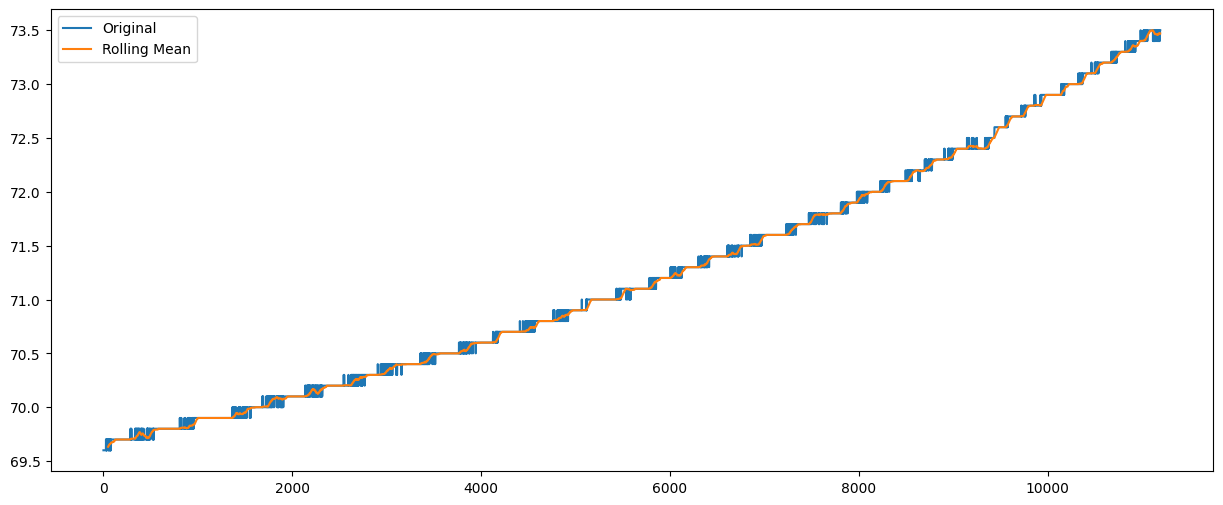

In [101]:
df['T703_roll_mean'] = df['T703'].rolling(window=50).mean()

plt.figure(figsize=(15,6))
plt.plot(df['T703'], label='Original')
plt.plot(df['T703_roll_mean'], label='Rolling Mean')
plt.legend()
plt.show()

In [102]:
z = (df['T703'] - df['T703'].mean()) / df['T703'].std()
df['z_score'] = z

df[df['z_score'].abs() > 3].head()

,LS701,LS702,T701,T702,T703,T704,T706,T708,T709,T711,...,T705,FT703,FT704,PDI701,PDI702,PY23,FYI702,anomaly,T703_roll_mean,z_score


In [103]:
df.groupby('anomaly').mean()

,LS701,LS702,T701,T702,T703,T704,T706,T708,T709,T711,T712,T705,FT703,FT704,PDI701,PDI702,PY23,FYI702,T703_roll_mean,z_score
anomaly,,,,,,,,,,,,,,,,,,,,
0,0.999263,1.0,442.984891,70.249793,71.195189,69.998498,70.002364,70.008617,69.411589,63.337766,63.338066,63.299254,0.109870,0.518044,0.624362,2.998327,499.894788,6.917501,71.193797,-0.043952
1,1.000000,1.0,443.579215,70.242587,72.756831,69.998837,70.010174,69.999419,70.369767,63.314244,63.322093,63.185465,0.134302,0.578198,0.639244,2.735756,499.517297,6.867006,72.751622,1.386412


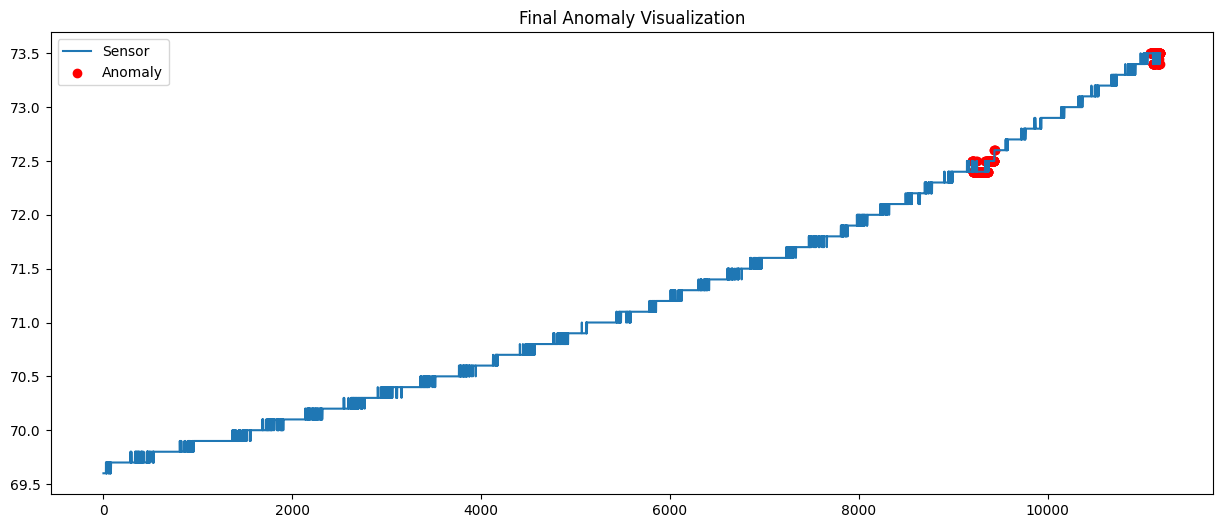

In [104]:
plt.figure(figsize=(15,6))

plt.plot(df['T703'], label='Sensor')
plt.scatter(df[df['anomaly']==1].index,
            df[df['anomaly']==1]['T703'],
            color='red', label='Anomaly')

plt.legend()
plt.title("Final Anomaly Visualization")
plt.show()

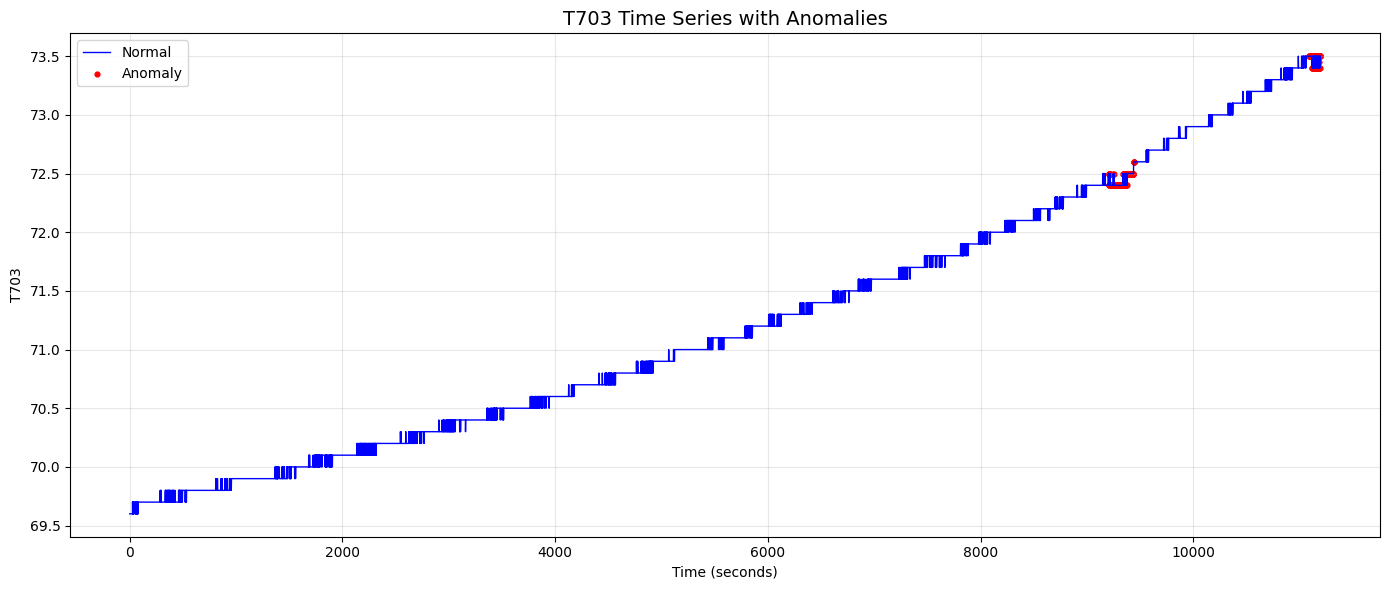

In [105]:
# If you don't already have a time axis
if 'time' not in df.columns:
    df['time'] = range(len(df))

sensor = 'T703'  # you can change this

plt.figure(figsize=(14,6))

# Plot normal behavior
plt.plot(df['time'], df[sensor], label='Normal', color='blue', linewidth=1)

# Highlight anomalies
anomalies = df[df['anomaly'] == 1]
plt.scatter(anomalies['time'], anomalies[sensor],
            color='red', label='Anomaly', s=12)

# Styling
plt.title(f"{sensor} Time Series with Anomalies", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel(sensor)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [106]:
import numpy as np

# Select only sensor columns (exclude labels/time if present)
sensor_cols = df.select_dtypes(include=[np.number]).columns
sensor_cols = [col for col in sensor_cols if col not in ['anomaly', 'time']]

# Compute Z-score for all sensors
z_scores = (df[sensor_cols] - df[sensor_cols].mean()) / df[sensor_cols].std()

# Detect outliers (|Z| > 3)
outliers = np.abs(z_scores) > 3

# Summary
outlier_counts = outliers.sum().sort_values(ascending=False)
total_outliers = outliers.sum().sum()
total_points = df[sensor_cols].shape[0] * df[sensor_cols].shape[1]

print("Total outlier points:", total_outliers)
print("Outlier percentage:", (total_outliers / total_points) * 100)

outlier_counts

Total outlier points: 1479
Outlier percentage: 0.6605627512282269


T704              656
T708              205
T706              166
FT703             105
FT704              88
PDI702             78
T705               74
T701               71
PY23               21
LS701               8
PDI701              7
T703_roll_mean      0
FYI702              0
T712                0
LS702               0
T711                0
T709                0
T703                0
T702                0
z_score             0
dtype: int64

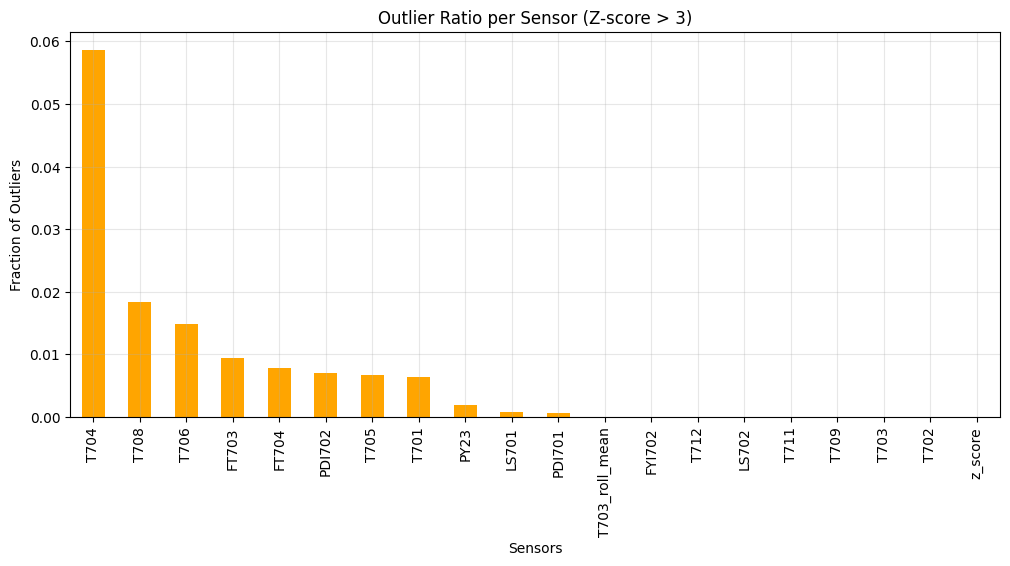

In [107]:
import matplotlib.pyplot as plt

outlier_ratio = outliers.mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
outlier_ratio.plot(kind='bar', color='orange')

plt.title("Outlier Ratio per Sensor (Z-score > 3)")
plt.ylabel("Fraction of Outliers")
plt.xlabel("Sensors")
plt.grid(alpha=0.3)

plt.show()

In [108]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Select sensor columns
sensor_cols = df.select_dtypes(include=[np.number]).columns
sensor_cols = [col for col in sensor_cols if col not in ['anomaly', 'time']]

# Standardize (important for PCA)
X = df[sensor_cols]
X_scaled = (X - X.mean()) / X.std()

# PCA to 2D
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Add to dataframe
df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

# Plot system state
plt.figure(figsize=(12,6))

plt.plot(df['PC1'], label='PC1 (System State 1)', alpha=0.7)
plt.plot(df['PC2'], label='PC2 (System State 2)', alpha=0.7)

# Highlight anomalies (if available)
if 'anomaly' in df.columns:
    anomalies = df[df['anomaly'] == 1]
    plt.scatter(anomalies.index, anomalies['PC1'],
                color='red', s=10, label='Anomaly')

plt.title("System State Evolution Over Time (PCA)")
plt.xlabel("Time Index")
plt.ylabel("Principal Component Value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import numpy as np

sensor_cols = df.select_dtypes(include=[np.number]).columns
sensor_cols = [col for col in sensor_cols if col not in ['anomaly', 'time']]

# count missing values per column
missing_counts = df[sensor_cols].isnull().sum().sort_values(ascending=False)

missing_counts

T703_roll_mean    49
LS701              0
LS702              0
FYI702             0
PY23               0
PDI702             0
PDI701             0
FT704              0
FT703              0
T705               0
T712               0
T711               0
T709               0
T708               0
T706               0
T704               0
T703               0
T702               0
T701               0
z_score            0
dtype: int64

Dropped sensor: T703


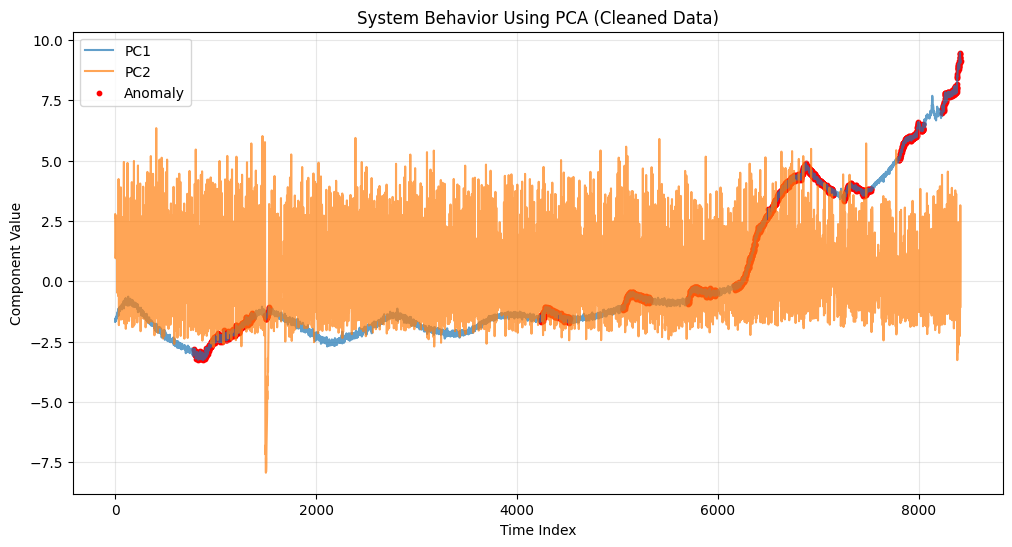

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# 1. Select sensor columns
# -----------------------------
sensor_cols = df.select_dtypes(include=[np.number]).columns
sensor_cols = [col for col in sensor_cols if col not in ['anomaly', 'time']]

# -----------------------------
# 2. Drop bad sensor
# -----------------------------
if 'T703' in sensor_cols:
    sensor_cols.remove('T703')
    print("Dropped sensor: T703")

# -----------------------------
# 3. Remove columns that are fully NaN
# -----------------------------
sensor_cols = [col for col in sensor_cols if df[col].notna().sum() > 0]

# -----------------------------
# 4. Handle missing values (safe)
# -----------------------------
df[sensor_cols] = df[sensor_cols].ffill().bfill()

# FINAL SAFETY CHECK (important)
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].mean())

# -----------------------------
# 5. Standardize
# -----------------------------
X = df[sensor_cols]
X_scaled = (X - X.mean()) / X.std()

# Remove any remaining NaN columns (extra safety)
X_scaled = X_scaled.dropna(axis=1)

# -----------------------------
# 6. PCA
# -----------------------------
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

# -----------------------------
# 7. Plot
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(df['PC1'], label='PC1', alpha=0.7)
plt.plot(df['PC2'], label='PC2', alpha=0.7)

if 'anomaly' in df.columns:
    anomalies = df[df['anomaly'] == 1]
    plt.scatter(anomalies.index, anomalies['PC1'],
                color='red', s=10, label='Anomaly')

plt.title("System Behavior Using PCA (Cleaned Data)")
plt.xlabel("Time Index")
plt.ylabel("Component Value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
import pandas as pd
import os

val_path = "../data/val/"
label_path = "../data/val_labels/"

print("=== CLASS IMBALANCE PER VALIDATION RUN ===\n")

for i in range(1, 11):
    file = f"series_{i:03d}.csv"
    
    labels = pd.read_csv(os.path.join(label_path, file))
    
    total = len(labels)
    anomalies = labels["label"].sum()
    normal = total - anomalies
    
    print(f"RUN {i}")
    print(f"Total samples   : {total}")
    print(f"Normal (0)      : {normal}")
    print(f"Anomaly (1)     : {anomalies}")
    print(f"Anomaly ratio   : {anomalies/total:.4f}")
    print("-" * 40)

=== CLASS IMBALANCE PER VALIDATION RUN ===

RUN 1
Total samples   : 8414
Normal (0)      : 5251
Anomaly (1)     : 3163
Anomaly ratio   : 0.3759
----------------------------------------
RUN 2
Total samples   : 11195
Normal (0)      : 10851
Anomaly (1)     : 344
Anomaly ratio   : 0.0307
----------------------------------------
RUN 3
Total samples   : 2070
Normal (0)      : 1219
Anomaly (1)     : 851
Anomaly ratio   : 0.4111
----------------------------------------
RUN 4
Total samples   : 7353
Normal (0)      : 7297
Anomaly (1)     : 56
Anomaly ratio   : 0.0076
----------------------------------------
RUN 5
Total samples   : 7156
Normal (0)      : 6987
Anomaly (1)     : 169
Anomaly ratio   : 0.0236
----------------------------------------
RUN 6
Total samples   : 8126
Normal (0)      : 6378
Anomaly (1)     : 1748
Anomaly ratio   : 0.2151
----------------------------------------
RUN 7
Total samples   : 8896
Normal (0)      : 7646
Anomaly (1)     : 1250
Anomaly ratio   : 0.1405
-------------

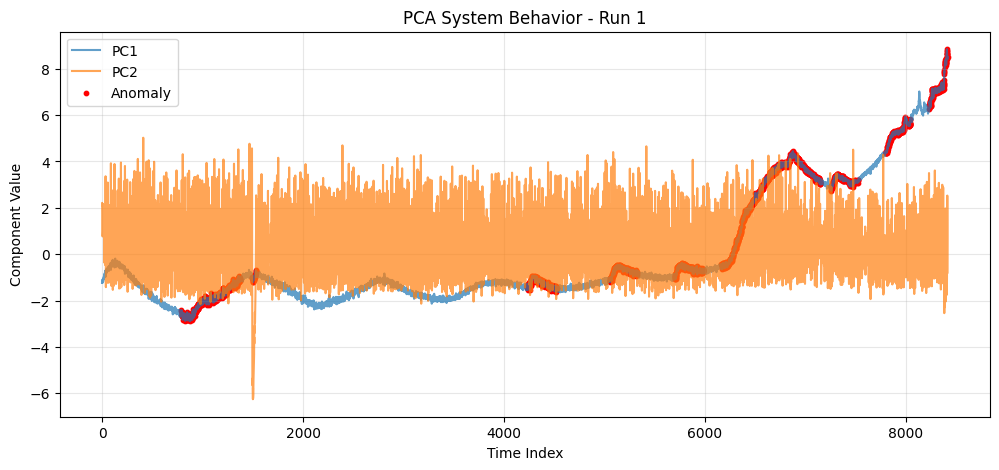

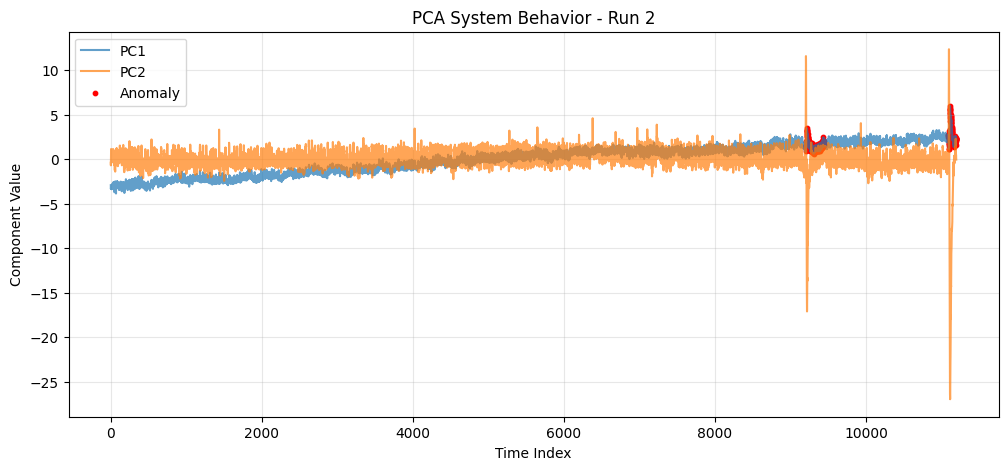

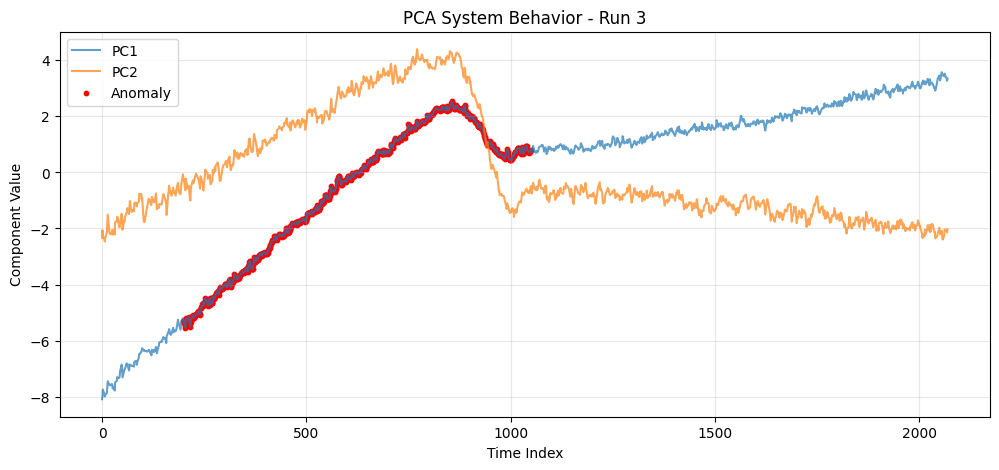

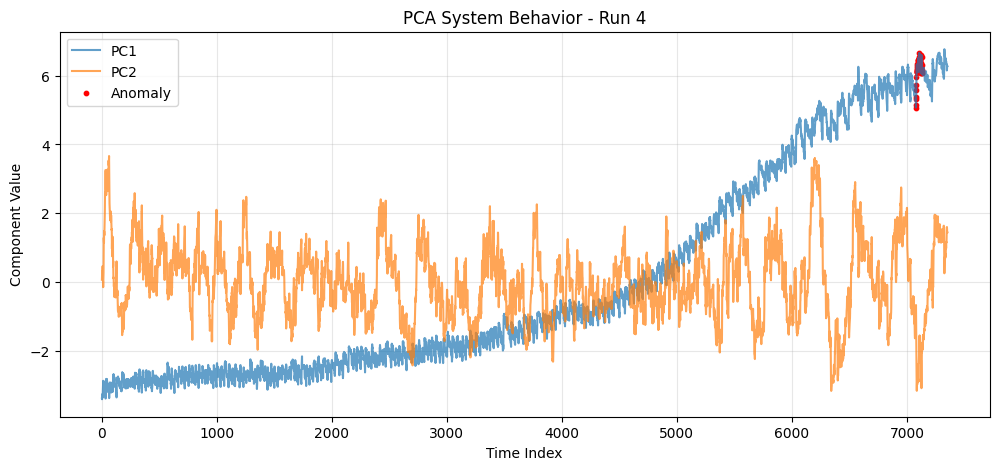

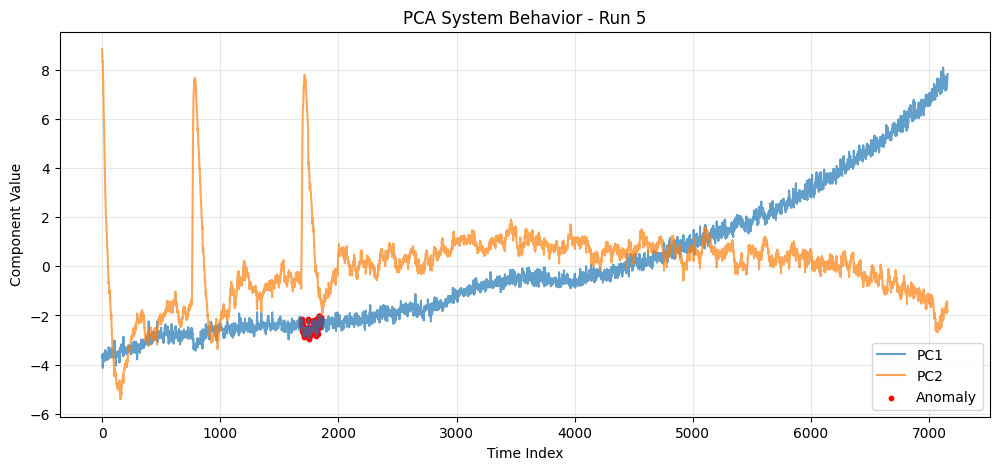

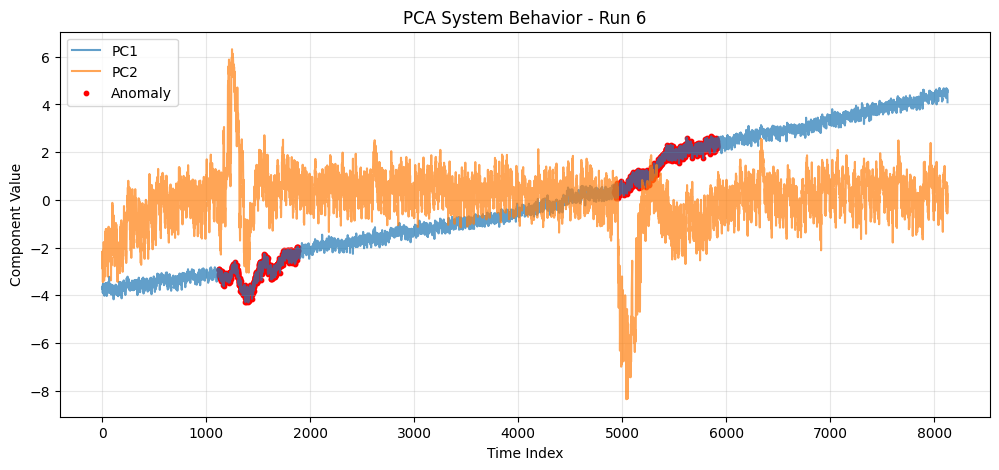

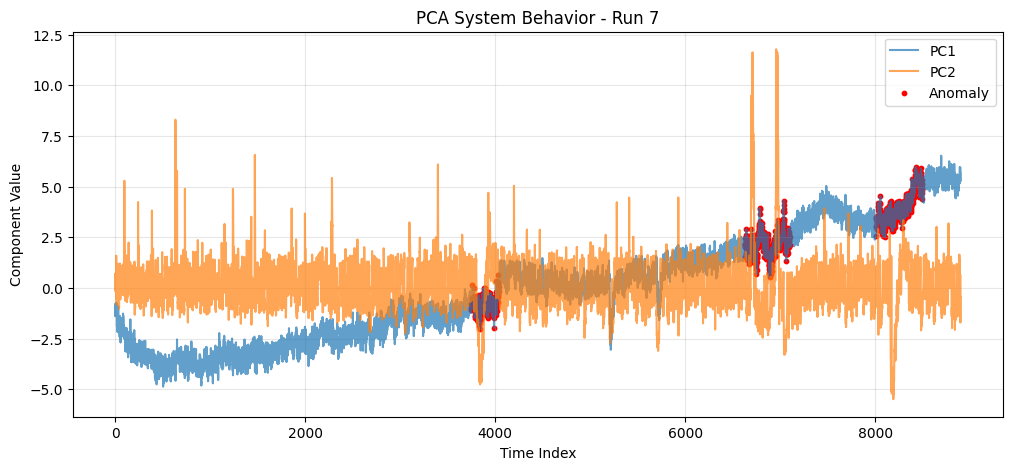

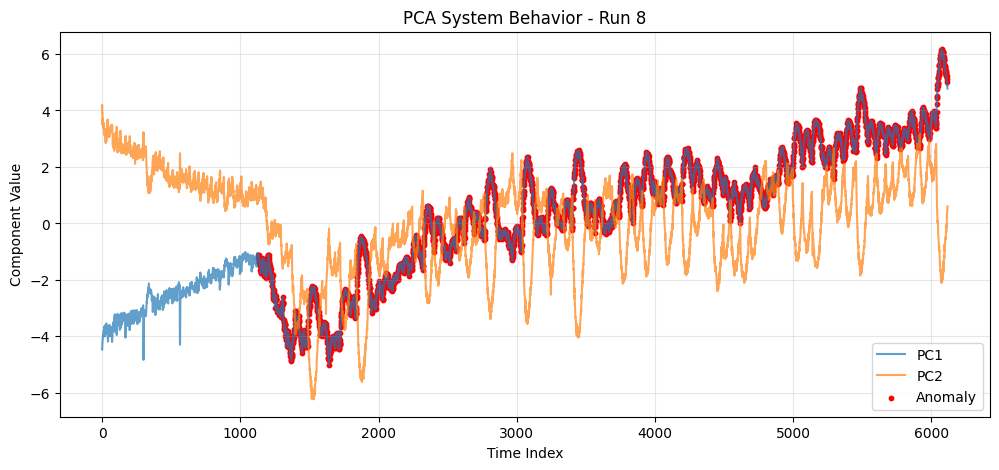

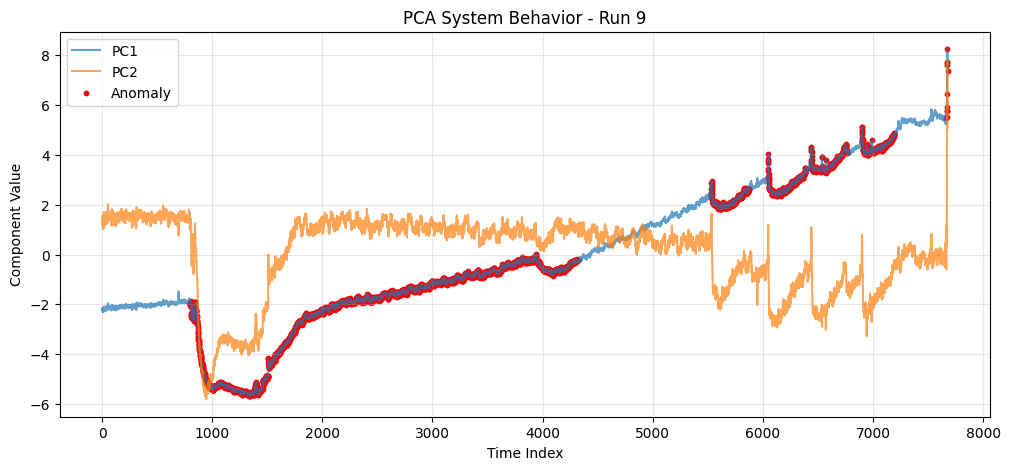

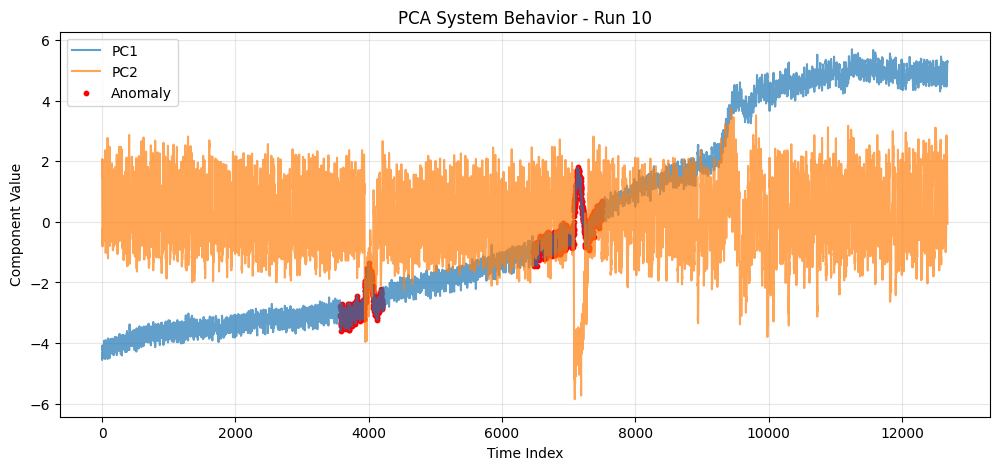

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

val_path = "../data/val/"
label_path = "../data/val_labels/"

# -----------------------------
# SENSOR COLUMNS (fixed idea)
# -----------------------------
sensor_cols = [
    "LS701","LS702","T701","T702","T703","T704","T706","T708",
    "T709","T711","T712","T705","FT703","FT704",
    "PDI701","PDI702","PY23","FYI702"
]

# -----------------------------
# LOOP THROUGH ALL VALIDATION RUNS
# -----------------------------
for i in range(1, 11):
    
    file = f"series_{i:03d}.csv"
    
    # load data
    df = pd.read_csv(os.path.join(val_path, file))
    labels = pd.read_csv(os.path.join(label_path, file))
    
    df["label"] = labels["label"].values
    df["run_id"] = i
    
    # -----------------------------
    # CLEANING (run-wise safe)
    # -----------------------------
    df[sensor_cols] = df[sensor_cols].ffill().bfill()
    df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].mean())
    
    # -----------------------------
    # PCA
    # -----------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[sensor_cols])
    
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    
    df["PC1"] = components[:, 0]
    df["PC2"] = components[:, 1]
    
    # -----------------------------
    # PLOT (same style for every run)
    # -----------------------------
    plt.figure(figsize=(12,5))
    
    plt.plot(df["PC1"], label="PC1", alpha=0.7)
    plt.plot(df["PC2"], label="PC2", alpha=0.7)
    
    anomalies = df[df["label"] == 1]
    plt.scatter(
        anomalies.index,
        anomalies["PC1"],
        color="red",
        s=10,
        label="Anomaly"
    )
    
    plt.title(f"PCA System Behavior - Run {i}")
    plt.xlabel("Time Index")
    plt.ylabel("Component Value")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.show()